In [1]:
import os

from dotenv import load_dotenv

load_dotenv(override=True)

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#15803d); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🧱 Context Isolation:子 Agent

</div>

<img src="./assets/agent_header_subagent.png" width="800" style="display:block; margin-left:0;">

context 一长就会出现各种麻烦,其中最致命的是 **"context clash"(语境冲突)/ "context confusion"(语境混乱)** —— 同一个 context 里混着多个目标,模型不知道该听谁的,性能下降。

[**Context isolation**](https://blog.langchain.com/context-engineering-for-agents/) 是对症下药:把任务**派发给专职子 agent**,每个子 agent 在自己**独立的 context 窗口**里跑,详见 Anthropic 的 [multi-agent research system](https://www.anthropic.com/engineering/multi-agent-research-system)。

#### 🛡️ 这套做法能避免的 4 个问题

| 问题 | 解释 |
|---|---|
| 💥 **Context clash** | 多目标互相矛盾 |
| 😵 **Context confusion** | 相似信息混淆 |
| ☠️ **Context poisoning** | 错误信息污染了后续推理 |
| 🧊 **Context dilution** | 关键信息被噪音淹没 |

### 🚀 Sub-agent delegation

![./assets/subagents.png](./assets/subagents.png)

#### 💡 核心思路

- 🛠️ 给每个子 agent **定制工具集**(只给它需要的)
- 🗂️ 子 agent 注册到一个 dict,**`subagent_type` 是 key**
- 📤 主 agent 通过 `task(description, subagent_type)` **派发任务**
- 🔒 子 agent **完全隔离**于父 context
- 📥 结果以一条 `ToolMessage` 回给父 agent → 保持职责清晰

> 💡 *2026 年观察*:multi-agent 架构(supervisor + workers)已经是 Claude Code、Devin、Cursor Composer 等生产系统的标配。理解这一节 = 理解它们的"派单机制"。

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

### ⚠️ 改名提示

`create_react_agent` 在 **1.0 版本** 中从 LangGraph 迁到了 LangChain,并改名为 **`create_agent`**(视频是录制后才改的)。本课所有 notebook 都已更新到新接口。

</div>

## 🪜 Step 1:定义子 Agent

先定义"用户怎么描述一个子 agent":

```python
from typing_extensions import TypedDict

class SubAgent(TypedDict):
    """专职子 agent 的配置。"""

    name: str                        # 唯一标识
    description: str                 # 派单时主 agent 看的描述
    prompt: str                      # 系统 prompt(指导子 agent 怎么干活)
    tools: NotRequired[list[str]]    # 可选:限定它能用哪些工具
```

然后用这些配置 **批量造子 agent**:

```python
agents: list[SubAgent] = ...
subagents = {
    agent['name']: create_agent(
        model=model,
        prompt=agent['prompt'],
        tools=get_tools(agent['tools']),
        ...
    )
}
```

## 🪜 Step 2:写一个 `task` 工具,让主 agent 能派单

逻辑伪代码:

```python
def task(
    description: str,    # 子 agent 要做的事
    subagent_type: str,  # 用哪个子 agent
):
    # 1. 构造一份"干净"的 messages,只放 description
    # 2. 调用子 agent
    # 3. 用 Command 把"子 agent 的回答" + "文件改动" 并入父 state
```

#### 🔧 完整实现

```python
@tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
def task(
    description: str,
    subagent_type: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
):
    """把任务派发给隔离 context 的子 agent。"""

    # 校验:请求的子 agent 类型必须存在
    if subagent_type not in agents:
        return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

    sub_agent = agents[subagent_type]

    # 🔒 关键一步:用"只包含 description"的 messages 替换 state
    # → 这就是 context 隔离 —— 子 agent 看不到父历史
    state["messages"] = [{"role": "user", "content": description}]

    # 在隔离 context 里执行子 agent
    result = sub_agent.invoke(state)

    # 用 Command 把成果回填父 state
    return Command(
        update={
            "files": result.get("files", {}),   # 把文件改动合并回父 state
            "messages": [
                # 子 agent 的最终回答 → 作为一条 ToolMessage 给父 agent 看
                ToolMessage(
                    result["messages"][-1].content,
                    tool_call_id=tool_call_id
                )
            ],
        }
    )

return task
```

> 🔑 **核心一行**:`state["messages"] = [{"role": "user", "content": description}]` —— 这一句**完全擦掉了父 context**,只把任务描述留给子 agent。这就是"context 隔离"。

In [3]:
%%writefile ../src/deep_agents_from_scratch/task_tool.py

import sys
sys.path.append("../src")

"""Task delegation tools for context isolation through sub-agents.

This module provides the core infrastructure for creating and managing sub-agents
with isolated contexts. Sub-agents prevent context clash by operating with clean
context windows containing only their specific task description.
"""

from typing import Annotated, NotRequired
from typing_extensions import TypedDict

from langchain_core.messages import ToolMessage
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState  # updated 1.0
from langchain.agents import create_agent  # updated 1.0

from langgraph.types import Command

from deep_agents_from_scratch.prompts import TASK_DESCRIPTION_PREFIX
from deep_agents_from_scratch.state import DeepAgentState


class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

    This function implements the core pattern for spawning specialized sub-agents with
    isolated contexts, preventing context clash and confusion in complex multi-step tasks.

    Args:
        tools: List of available tools that can be assigned to sub-agents
        subagents: List of specialized sub-agent configurations
        model: The language model to use for all agents
        state_schema: The state schema (typically DeepAgentState)

    Returns:
        A 'task' tool that can delegate work to specialized sub-agents
    """
    # Create agent registry
    agents = {}

    # Build tool name mapping for selective tool assignment
    tools_by_name = {}
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # Create specialized sub-agents based on configurations
    for _agent in subagents:
        if "tools" in _agent:
            # Use specific tools if specified
            _tools = [tools_by_name[t] for t in _agent["tools"]]
        else:
            # Default to all tools
            _tools = tools
        agents[_agent["name"]] = create_agent(   # updated 1.0
            model, system_prompt=_agent["prompt"], tools=_tools, state_schema=state_schema
        )

    # Generate description of available sub-agents for the tool description
    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}" for _agent in subagents
    ]

    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str,
        subagent_type: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Delegate a task to a specialized sub-agent with isolated context.

        This creates a fresh context for the sub-agent containing only the task description,
        preventing context pollution from the parent agent's conversation history.
        """
        # Validate requested agent type exists
        if subagent_type not in agents:
            return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

        # Get the requested sub-agent
        sub_agent = agents[subagent_type]

        # Create isolated context with only the task description
        # This is the key to context isolation - no parent history
        state["messages"] = [{"role": "user", "content": description}]

        # Execute the sub-agent in isolation
        result = sub_agent.invoke(state)

        # Return results to parent agent via Command state update
        return Command(
            update={
                "files": result.get("files", {}),  # Merge any file changes
                "messages": [
                    # Sub-agent result becomes a ToolMessage in parent context
                    ToolMessage(
                        result["messages"][-1].content, tool_call_id=tool_call_id
                    )
                ],
            }
        )

    return task

Overwriting ../src/deep_agents_from_scratch/task_tool.py


现在你有了一套**用配置生成子 agent**的常规流程。下面就用它来定义具体子 agent,然后让系统通过 `task` 工具调用它们。

回顾 `_create_task_tool` 的入参 —— 它接收一个 `SubAgent` 列表:

```python
class SubAgent(TypedDict):
    """专职子 agent 的配置。"""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """生成 task 派发工具,实现 context 隔离。"""
```

#### 🎭 SubAgent 的"双重身份"

子 agent **既是工具,又是 agent**:

| 身份 | 需要什么 |
|---|---|
| 🔧 **作为工具** | 主 agent 需要知道它**能干什么、怎么调用** → 由 `name` + `description` 提供 |
| 🤖 **作为 agent** | 它自己需要 **怎么干活的指令 + 干活的工具** → 由 `prompt` + `tools` 提供 |

#### 🧑‍🔬 示例:研究型子 agent

```python
research_sub_agent = {
    "name": "research-agent",
    "description": "把研究任务派给这个 sub-agent。每次只给它一个主题。",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}
```

注意子 agent **只拿到具体任务 + 必要工具**,在自己的 context 里跑,context 只有这一个任务描述。这就是 [context engineering](https://blog.langchain.com/context-engineering-for-agents/) —— 让子 agent 的工作空间**干净、专注、不受污染**。

#### 📜 主 agent 的 prompt 要增加"派单说明"

接下来这条 prompt 教主 agent **怎么调用子 agent**,并加入 **并行研究** 的指引。

In [4]:
import sys
sys.path.append("../src")
from utils import show_prompt

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│     - description: Clear, specific research question or task                                                    │
│     - subagent_type: Type of agent to use (e.g., "research-agent")                                              │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│     - reflection: Your detailed reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element 

🧪 下面搭一套 **supervisor + 子 agent** 的研究系统。当前是 **mock 版**(用预设搜索结果),目的是把"零件如何组合"演示出来。下一节会做完整版。

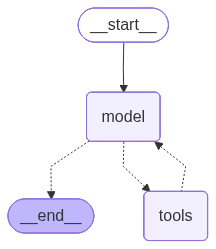

In [5]:
from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent # updated in 1.0

import sys
sys.path.append("../src")
from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """You are a researcher. Research the topic provided to you. IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the provided topic."""

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-5", temperature=0.0)

# Tools for sub-agent
sub_agent_tools = [web_search]

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# Tools
delegation_tools = [task_tool]

# Create agent with system prompt
agent = create_agent(
    model,
    delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=DeepAgentState,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [6]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll research the Model Context Protocol (MCP) for you.                                                         │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Research and provide a comprehensive overview of Model Context Protocol (MCP). Include what   │
│ it is, its purpose, key features, how it works, who developed it, use cases, and any other important            │
│ information about this protocol.",                                                                              │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: toolu_01Wj3ZFRJKXoD8nL6XCTDPco                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Based on my research, here's a comprehensive overview of the Model Context Protocol (MCP):                      │
│                                                                                                                 │
│ ## What is Model Context Protocol (MCP)?                                                                        │
│                                                                                                                 │
│ The Model Context Protocol (MCP) is an **open standard protocol** that serves as a standardized communication   │
│ layer between AI models and external systems. It provides a unified framework for AI assistants to interact     │
│ with various data sources, tools, databases, and services.                                                      │
│                                                                                                                 │
│ ## Developer                                                                                                    │
│                                                                                                                 │
│ **Anthropic** developed the Model Context Protocol as an open standard to address the fragmentation in          │
│ AI-to-system integrations.                                                                                      │
│                                                                                                                 │
│ ## Purpose                                                                                                      │
│                                                                                                                 │
│ The primary purpose of MCP is to:                                                                               │
│ - **Simplify integration** between AI models and external systems                                               │
│ - **Standardize communication** across different data sources and tools                                         │
│ - **Enable seamless data exchange** using a unified language                                                    │
│ - **Reduce complexity** in connecting AI assistants to various services                                         │
│ - **Eliminate the need** for custom integrations for each data source                                           │
│                                                                                                                 │
│ ## Key Features                                                                                                 │
│                                                                                                                 │
│ 1. **Standardized Communication Layer**: Provides a consistent interface for AI models to interact with         │
│ external systems                                                                                                │
│                                                                                                                 │
│ 2. **Universal Compatibility**: Works across different tools, databases, and services without requiring custom  │
│ integrations for each                                                                                           │
│                                                                                                                 │
│ 3. **Open Standard**: Being open allows for widespread adoption and community contribution                      │
│                                                                                                                 │
│ 4. **Efficient Data Access**: Enables AI models to access and utilize data from various sources in a consistent │
│ manner                                                 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## Overview of Model Context Protocol (MCP)                                                                     │
│                                                                                                                 │
│ The **Model Context Protocol (MCP)** is an open standard protocol developed by **Anthropic** that serves as a   │
│ standardized communication layer between AI models and external systems.                                        │
│                                                                                                                 │
│ ### What It Does                                                                                                │
│                                                                                                                 │
│ MCP provides a unified framework that allows AI assistants to interact with various data sources, tools,        │
│ databases, and services through a consistent interface. Think of it as a "universal translator" that enables AI │
│ models to communicate with different systems without requiring custom integrations for each one.                │
│                                                                                                                 │
│ ### Key Purpose                                                                                                 │
│                                                                                                                 │
│ The protocol was created to:                                                                                    │
│ - **Simplify integration** between AI models and external systems                                               │
│ - **Standardize communication** across different data sources and tools                                         │
│ - **Eliminate fragmentation** in AI-to-system integrations                                                      │
│ - **Reduce development complexity** by providing a common language                                              │
│                                                                                                                 │
│ ### How It Works                                                                                                │
│                                                                                                                 │
│ MCP acts as an intermediary that:                                                                               │
│ - Establishes a standardized format for requests and responses                                                  │
│ - Facilitates bidirectional communication between AI models and external systems                                │
│ - Provides consistent interfaces regardless of the underlying system being accessed                             │
│ - Enables seamless data exchange across different platforms                                                     │
│                                                                                                                 │
│ ### Common Use Cases                                                                                            │
│                                                                                                                 │
│ - **Database Integration**: Connecting AI to various database systems                                           │
│ - **Tool Access**: Enabling AI assistants to use external APIs and tools                                        │
│ - **Enterprise Services**: Linking AI with business applications                                                │
│ - **Data Retrieval**: Accessing information from multiple sources seamlessly                                    │
│ - **Workflow Automation**: Facilitating AI-driven autom

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

🔭 **LangSmith Trace**:[查看本次执行](https://smith.langchain.com/public/26cc1c2b-e785-4c6d-a2a7-c30a31875fc7/r)
<!-- https://smith.langchain.com/public/edc4e672-db9c-457a-953d-f62e7813591c/r -->

</div>

In [7]:
result["messages"]

[HumanMessage(content='Give me an overview of Model Context Protocol (MCP).', additional_kwargs={}, response_metadata={}, id='12112272-a37a-46c1-a33b-3170f6571cbb'),
 AIMessage(content=[{'text': "I'll research the Model Context Protocol (MCP) for you.", 'type': 'text'}, {'id': 'toolu_01Wj3ZFRJKXoD8nL6XCTDPco', 'caller': {'type': 'direct'}, 'input': {'description': 'Research and provide a comprehensive overview of Model Context Protocol (MCP). Include what it is, its purpose, key features, how it works, who developed it, use cases, and any other important information about this protocol.', 'subagent_type': 'research-agent'}, 'name': 'task', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01MS3QDGmH4Wb3SWrgjjy3NU', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'c